
## Introduction

Genome-wide association studies, or GWAS, have identified many genetic variants associated with complex traits and diseases. However, after identifying a GWAS locus, one important question remains:

> Which gene or biological mechanism is responsible for the association?

Many GWAS variants are located in non-coding regions of the genome. They may not directly change protein sequence, but they may influence disease by changing gene regulation. This is where eQTL data becomes useful.

An eQTL is a genetic variant associated with gene expression. If a GWAS variant for a disease is also an eQTL for a nearby gene, it may suggest that the disease association works through altered gene expression.

However, this interpretation is not always safe.

The GWAS signal and the eQTL signal may appear to overlap simply because nearby SNPs are correlated through linkage disequilibrium, or LD. Therefore, visual overlap between GWAS and eQTL signals does not automatically mean that the same causal variant is responsible for both traits.

Colocalization analysis tries to answer this specific question:

> Are the GWAS and eQTL signals driven by the same causal variant?

## Why Colocalization is Important

Suppose a GWAS identifies a region associated with depression. In the same region, an eQTL study shows that a nearby SNP is associated with expression of Gene X.

A simple interpretation might be:

Gene X is involved in depression.

But this may be wrong.

There are at least two possible explanations.

First, the same causal variant may influence both Gene X expression and depression risk. This would support a shared biological mechanism.

Second, two different causal variants may exist in the same region. One variant may affect depression risk, while another nearby variant may affect Gene X expression. Because the variants are in LD, the signals may look similar even though they are biologically separate.

Colocalization is designed to distinguish between these two possibilities.

## Relationship Between GWAS, eQTL, and Colocalization

GWAS asks:

Which variants are associated with disease or trait risk?

eQTL analysis asks:

Which variants are associated with gene expression?

Colocalization asks:

Are the GWAS and eQTL associations likely to share the same causal variant?

A simple post-GWAS workflow is:

```text
GWAS signal
    ↓
Check eQTL signal
    ↓
Run colocalization
    ↓
Prioritize candidate gene
```

This is why colocalization is now widely used in post-GWAS interpretation, TWAS analysis, Mendelian Randomization, and drug target prioritization.

## The Five Colocalization Hypotheses

The classical Bayesian colocalization framework evaluates five hypotheses.

### H0: No Association With Either Trait

There is no evidence that variants in the region are associated with either trait.

```text
Trait 1: no association
Trait 2: no association
```

### H1: Association With Trait 1 Only

Only the first trait is associated in the region.

In many applications, trait 1 is the GWAS trait.

```text
GWAS trait: associated
eQTL trait: not associated
```

### H2: Association With Trait 2 Only

Only the second trait is associated in the region.

In many applications, trait 2 is gene expression.

```text
GWAS trait: not associated
eQTL trait: associated
```

### H3: Both Traits Associated, But Different Causal Variants

Both traits show association in the region, but the evidence suggests that they are driven by different causal variants.

```text
Variant A ──► Disease

Variant B ──► Gene Expression
```

This means there is no strong evidence for a shared biological mechanism.

### H4: Both Traits Associated and Share One Causal Variant

Both traits are associated, and the evidence suggests that the same causal variant drives both signals.

```text
Variant ──► Gene Expression
       └──► Disease Risk
```

This is the main colocalization scenario researchers usually hope to find.

## The Most Important Quantity: PP.H4

The coloc package reports posterior probabilities for each hypothesis.

The most important quantity is usually:

```text
PP.H4.abf
```

This means the posterior probability that both traits share the same causal variant.

A rough interpretation is:

```text
PP.H4 < 0.50       weak evidence for colocalization
PP.H4 0.50–0.80    moderate evidence
PP.H4 > 0.80       strong evidence
PP.H4 > 0.90       very strong evidence
```

These are not universal rules. The threshold depends on the study design, sample size, prior assumptions, and biological context.



In [1]:


## Install and Load Required Packages


# Install packages if needed
 #install.packages("coloc")
# install.packages("ggplot2")
# install.packages("dplyr")

library(coloc)
library(ggplot2)
library(dplyr)


This is coloc version 5.2.3


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





## Simulated Example Using the coloc Package

In this example, we simulate 100 SNPs from one genomic region. We create one GWAS signal and one eQTL signal. Both are given a strong effect at SNP 50, representing a simplified shared causal variant.

This is a toy example, but it helps us understand what the `coloc.abf()` function needs as input.

In [2]:
set.seed(42)

# Number of SNPs in the region
n_snps <- 100

# SNP IDs and positions
snp_ids <- paste0("rs", 1:n_snps)
position <- 1:n_snps

# Minor allele frequencies
maf <- runif(n_snps, min = 0.05, max = 0.50)

# Standard errors
gwas_se <- rep(0.05, n_snps)
eqtl_se <- rep(0.05, n_snps)

# Simulate small background effects
gwas_beta <- rnorm(n_snps, mean = 0, sd = 0.05)
eqtl_beta <- rnorm(n_snps, mean = 0, sd = 0.05)

# Add one shared causal signal at SNP 50
gwas_beta[50] <- 0.50
eqtl_beta[50] <- 0.60

# Create a data frame for visualization
sim_data <- data.frame(
  SNP = snp_ids,
  Position = position,
  MAF = maf,
  GWAS_Beta = gwas_beta,
  eQTL_Beta = eqtl_beta,
  GWAS_SE = gwas_se,
  eQTL_SE = eqtl_se
)

head(sim_data)

,SNP,Position,MAF,GWAS_Beta,eQTL_Beta,GWAS_SE,eQTL_SE
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,rs1,1,0.4616627,0.016096263,-0.002034924,0.05,0.05
2,rs2,2,0.4716839,-0.039191947,-0.077577241,0.05,0.05
3,rs3,3,0.1787628,0.078786376,0.058358477,0.05,0.05
4,rs4,4,0.4237014,0.032144965,-0.013682285,0.05,0.05
5,rs5,5,0.3387855,0.004488032,-0.023392266,0.05,0.05
6,rs6,6,0.2835932,0.013827537,-0.061912616,0.05,0.05


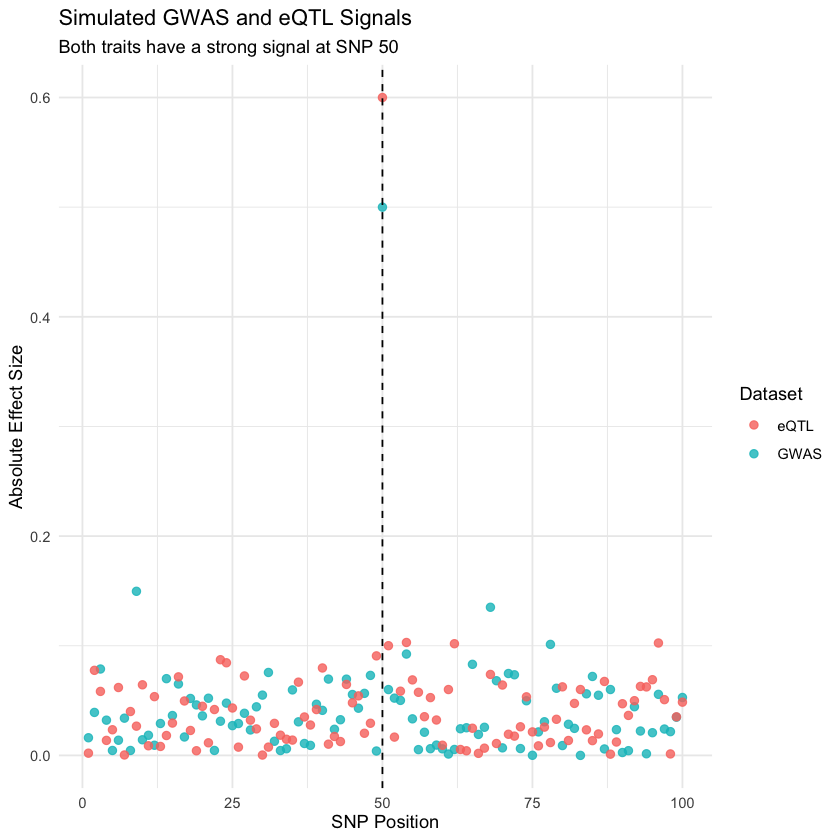

In [3]:
## Visualize the Simulated Signals

ggplot(sim_data, aes(x = Position)) +
  geom_point(aes(y = abs(GWAS_Beta), color = "GWAS"), size = 2, alpha = 0.8) +
  geom_point(aes(y = abs(eQTL_Beta), color = "eQTL"), size = 2, alpha = 0.8) +
  geom_vline(xintercept = 50, linetype = "dashed") +
  labs(
    title = "Simulated GWAS and eQTL Signals",
    subtitle = "Both traits have a strong signal at SNP 50",
    x = "SNP Position",
    y = "Absolute Effect Size",
    color = "Dataset"
  ) +
  theme_minimal()



## Prepare Data for coloc

The `coloc.abf()` function needs the GWAS and eQTL data as lists.

For the GWAS dataset, we use:

```text
type = "cc"
```

because the GWAS trait is treated as a case-control disease outcome.

For the eQTL dataset, we use:

```text
type = "quant"
```

because gene expression is a quantitative trait.

For quantitative traits, `coloc` needs either `sdY`, or enough information to estimate it. Here we set:

```text
sdY = 1
```

because this is a simulated example.

In [4]:
gwas_data <- list(
  beta = gwas_beta,
  varbeta = gwas_se^2,
  snp = snp_ids,
  MAF = maf,
  type = "cc",
  s = 0.30,
  N = 50000
)

eqtl_data <- list(
  beta = eqtl_beta,
  varbeta = eqtl_se^2,
  snp = snp_ids,
  MAF = maf,
  type = "quant",
  N = 1000,
  sdY = 1
)

In [5]:

## Run Colocalization Analysis

coloc_result <- coloc.abf(
  dataset1 = gwas_data,
  dataset2 = eqtl_data
)

coloc_result$summary

PP.H0.abf PP.H1.abf PP.H2.abf PP.H3.abf PP.H4.abf 
 3.43e-43  2.28e-27  1.51e-19  0.00e+00  1.00e+00 
[1] "PP abf for shared variant: 100%"


nsnps    PP.H0.abf    PP.H1.abf    PP.H2.abf    PP.H3.abf    PP.H4.abf 
1.000000e+02 3.432058e-43 2.278860e-27 1.506042e-19 0.000000e+00 1.000000e+00

## Examine Results

The output contains posterior probabilities for the five hypotheses considered by the coloc model.

```text
H0: Neither trait is associated in the region
H1: Only trait 1 is associated
H2: Only trait 2 is associated
H3: Both traits are associated, but with different causal variants
H4: Both traits are associated and share the same causal variant
```

The most important quantity is:

```text
PP.H4.abf
```

This tells us the posterior probability that the GWAS and eQTL signals are driven by the same causal variant.

For example, if the output shows:

```text
PP.H4.abf = 0.90
```

we would interpret this as strong evidence that the GWAS and eQTL signals colocalize.

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100,3.432058e-43,2.27886e-27,1.506042e-19,0,1


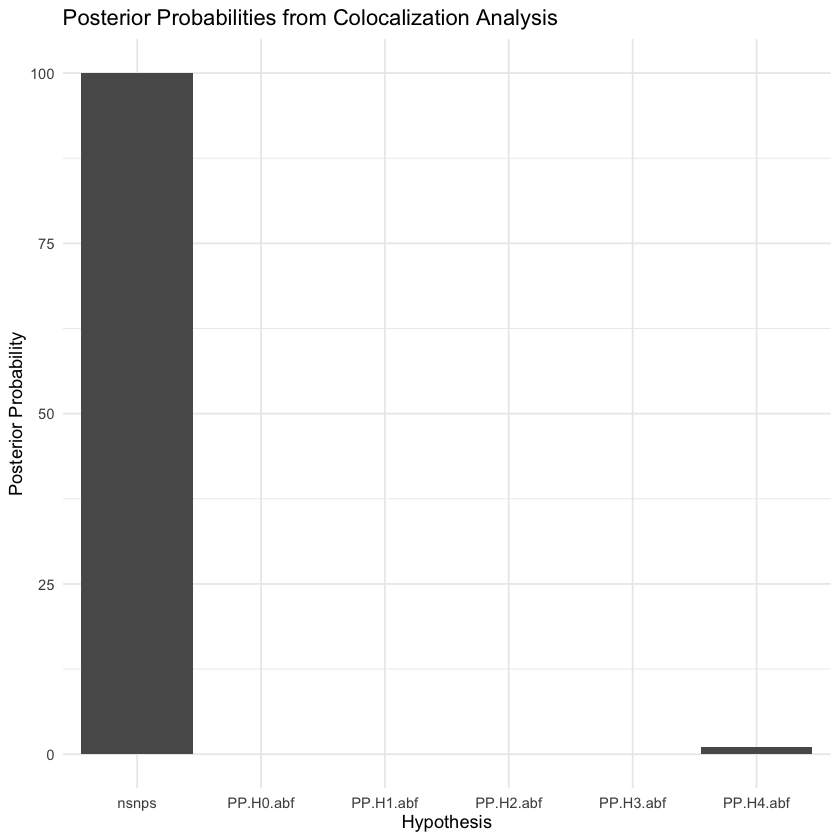

In [6]:
## Extract the Posterior Probabilities


posterior_probs <- as.data.frame(t(coloc_result$summary))

posterior_probs


## Visualize Posterior Probabilities


posterior_df <- data.frame(
  Hypothesis = names(coloc_result$summary),
  Posterior_Probability = as.numeric(coloc_result$summary)
)

ggplot(posterior_df, aes(x = Hypothesis, y = Posterior_Probability)) +
  geom_col() +
  labs(
    title = "Posterior Probabilities from Colocalization Analysis",
    x = "Hypothesis",
    y = "Posterior Probability"
  ) +
  theme_minimal()


## Understanding H3 vs H4

The distinction between H3 and H4 is one of the most important concepts in colocalization analysis.

A common misconception is that overlapping GWAS and eQTL association peaks automatically imply that the same variant is responsible for both signals. Because nearby variants are often correlated through LD, this assumption can be incorrect.

### H3: Different Causal Variants

A high posterior probability for H3 means that both traits are associated in the region, but they are probably driven by different causal variants.

Conceptually:

```text
Variant A ──► Disease

Variant B ──► Gene Expression
```

In this case, the region contains both a GWAS signal and an eQTL signal, but there is little evidence that the gene expression change explains the disease association.

### H4: Shared Causal Variant

A high posterior probability for H4 means that the same variant is likely responsible for both the GWAS and eQTL associations.

Conceptually:

```text
Variant
    │
    ├──► Gene Expression
    │
    └──► Disease Risk
```

This is often interpreted as evidence that altered gene expression may be involved in disease biology.

## Simulating a Different-Causal-Variant Scenario

Now we simulate a second example where the GWAS signal is strongest at SNP 40 and the eQTL signal is strongest at SNP 70.

This represents a situation where both traits are associated in the region, but likely through different causal variants.


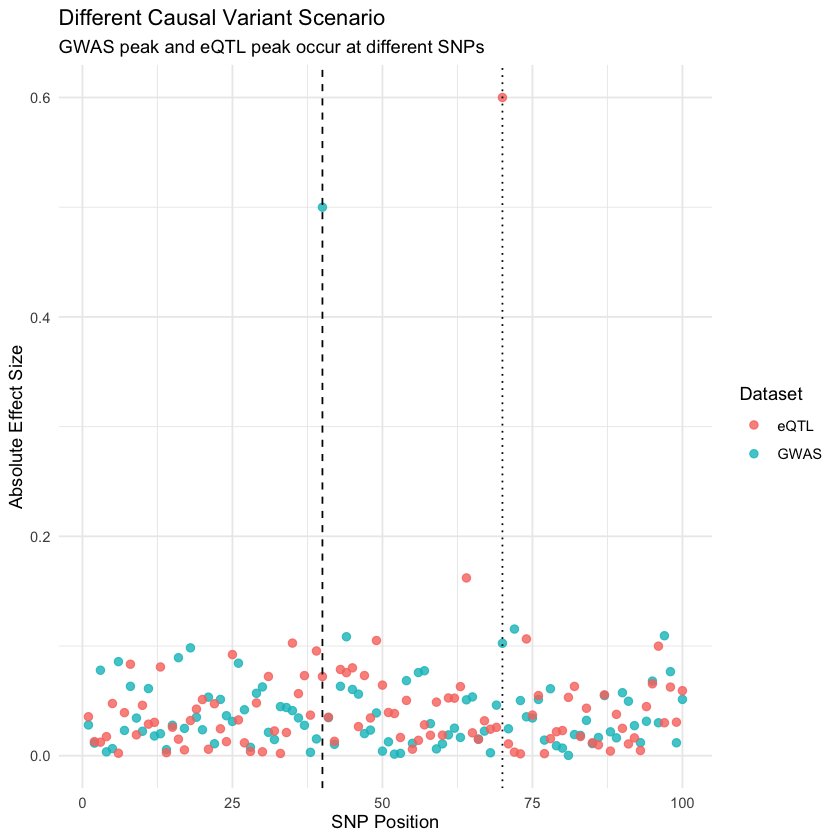

In [7]:
set.seed(123)

gwas_beta_diff <- rnorm(n_snps, mean = 0, sd = 0.05)
eqtl_beta_diff <- rnorm(n_snps, mean = 0, sd = 0.05)

# Different causal SNPs
gwas_beta_diff[40] <- 0.50
eqtl_beta_diff[70] <- 0.60

diff_data <- data.frame(
  SNP = snp_ids,
  Position = position,
  GWAS_Beta = gwas_beta_diff,
  eQTL_Beta = eqtl_beta_diff
)

ggplot(diff_data, aes(x = Position)) +
  geom_point(aes(y = abs(GWAS_Beta), color = "GWAS"), size = 2, alpha = 0.8) +
  geom_point(aes(y = abs(eQTL_Beta), color = "eQTL"), size = 2, alpha = 0.8) +
  geom_vline(xintercept = 40, linetype = "dashed") +
  geom_vline(xintercept = 70, linetype = "dotted") +
  labs(
    title = "Different Causal Variant Scenario",
    subtitle = "GWAS peak and eQTL peak occur at different SNPs",
    x = "SNP Position",
    y = "Absolute Effect Size",
    color = "Dataset"
  ) +
  theme_minimal()


In [8]:
gwas_data_diff <- list(
  beta = gwas_beta_diff,
  varbeta = gwas_se^2,
  snp = snp_ids,
  MAF = maf,
  type = "cc",
  s = 0.30,
  N = 50000
)

eqtl_data_diff <- list(
  beta = eqtl_beta_diff,
  varbeta = eqtl_se^2,
  snp = snp_ids,
  MAF = maf,
  type = "quant",
  N = 1000,
  sdY = 1
)

coloc_result_diff <- coloc.abf(
  dataset1 = gwas_data_diff,
  dataset2 = eqtl_data_diff
)

coloc_result_diff$summary

PP.H0.abf PP.H1.abf PP.H2.abf PP.H3.abf PP.H4.abf 
 3.43e-40  2.28e-24  1.51e-16  1.00e+00  2.64e-17 
[1] "PP abf for shared variant: 2.64e-15%"


nsnps    PP.H0.abf    PP.H1.abf    PP.H2.abf    PP.H3.abf    PP.H4.abf 
1.000000e+02 3.432058e-40 2.278860e-24 1.506042e-16 1.000000e+00 2.639762e-17

In this second example, we expect less support for H4 compared with the shared-causal-variant example. Depending on the simulated values and priors, H3 may become more prominent because both traits have signals but not at the same SNP.

## Why Visual Overlap Is Not Enough

It is tempting to look at two regional plots and decide whether the peaks overlap. However, nearby SNPs are often correlated because of LD.

This means two different causal variants can produce similar association patterns.

Therefore, colocalization is stronger than visual inspection because it formally compares hypotheses about shared and distinct causal variants.

## Colocalization and TWAS

Transcriptome-wide association studies, or TWAS, test whether genetically predicted gene expression is associated with a trait.

A simplified TWAS idea is:

```text
Genetic variants ──► Predicted gene expression ──► Disease trait
```

However, TWAS signals can arise because of LD or multiple nearby genes with correlated expression. Therefore, a significant TWAS result does not automatically prove that the gene is causal.

Colocalization is often used alongside TWAS.

A stronger interpretation is possible when:

```text
Gene is significant in TWAS
+
GWAS and eQTL signals colocalize
```

This combination gives more confidence that the gene may be biologically relevant.

## Colocalization and Mendelian Randomization

Mendelian Randomization, or MR, can be used to test whether genetically predicted exposure affects an outcome.

For gene expression studies, the exposure may be expression of a gene and the outcome may be disease risk.

MR asks:

Does gene expression causally affect disease?

Colocalization asks:

Do gene expression and disease share the same causal variant?

These are related but different questions.

If MR suggests a causal effect but colocalization is weak, the MR result may be driven by LD or pleiotropy. Therefore, colocalization is often an important sensitivity analysis for expression-based MR.

## Limitations of Classical Colocalization

The classical coloc method assumes one causal variant per region for each trait. This assumption may not always hold.

Real genetic loci can contain multiple independent signals.

Other limitations include:

```text
Incorrect LD structure
Poor variant coverage
Allele harmonization errors
Different ancestry between datasets
Weak eQTL sample size
Tissue mismatch
Multiple causal variants
```

Because of these limitations, colocalization should not be interpreted mechanically. A high PP.H4 is useful evidence, but it should be considered together with biology, tissue relevance, fine-mapping, and replication.

## Modern Extensions

Several newer methods extend classical colocalization.

### SuSiE-Coloc

SuSiE-coloc combines colocalization with fine-mapping and can handle multiple causal signals in a region.

### eCAVIAR

eCAVIAR jointly models colocalization and fine-mapping while accounting for LD.

### fastENLOC

fastENLOC is designed for large-scale enrichment and colocalization analyses across many loci and molecular traits.

These methods are useful when the simple one-causal-variant assumption is unrealistic.

## Practical Interpretation Checklist

When interpreting colocalization results, I would check the following:

```text
1. Is there a strong GWAS signal in the region?
2. Is there a strong eQTL signal in the same tissue?
3. Are the alleles harmonized correctly?
4. Are the GWAS and eQTL datasets ancestry-matched?
5. Is PP.H4 high?
6. Is PP.H3 also high?
7. Is the tissue biologically relevant?
8. Does the result agree with TWAS, MR, or functional evidence?
```

A high PP.H4 is helpful, but it is not the final proof of causality.

## Summary

Colocalization analysis is a key method in post-GWAS interpretation. It helps determine whether two association signals, such as a disease GWAS signal and an eQTL signal, are likely to share the same causal variant.

The main idea is simple but important:

```text
Overlapping association signals do not automatically mean shared causality.
```

The coloc framework evaluates five hypotheses: H0, H1, H2, H3, and H4. Among these, H4 is usually the most important because it represents evidence that both traits share one causal variant.

In practical genetic studies, colocalization is often used together with eQTL analysis, TWAS, MR, and fine-mapping to prioritize genes and biological mechanisms.

For researchers working with GWAS, FinnGen, UK Biobank, GTEx, PsychENCODE, or other molecular QTL resources, colocalization is one of the most useful tools for moving from statistical association toward biological interpretation.

## References

Giambartolomei, C. et al. Bayesian test for colocalisation between pairs of genetic association studies using summary statistics. PLoS Genetics, 2014.

Wallace, C. A more accurate method for colocalisation analysis allowing for multiple causal variants. PLoS Genetics, 2021.

GTEx Consortium. The GTEx Consortium atlas of genetic regulatory effects across human tissues. Science, 2020.

Hormozdiari, F. et al. Colocalization of GWAS and eQTL signals detects target genes. American Journal of Human Genetics, 2016.
